In [1]:

import sys
sys.path.append('..')
import pennylane as qml
import numpy as np

from QHyper.optimizers.qml_gradient_descent import QmlGradientDescent
from QHyper.solvers.QAOA.core import QAOA

## Workflow test problem

In [2]:
from QHyper.problems.Workflowtest import WorkflowtestProblem

In [3]:
wft = WorkflowtestProblem()

6.0*x0 + 8.0*x1 + 8.0*x2 + 3.0*x3 + 4.0*x4 + 4.0*x5 + 12.0*x6 + 16.0*x7 + 16.0*x8
[x0**2 + 2*x0*x1 + 2*x0*x2 - 2*x0 + x1**2 + 2*x1*x2 - 2*x1 + x2**2 - 2*x2 + x3**2 + 2*x3*x4 + 2*x3*x5 - 2*x3 + x4**2 + 2*x4*x5 - 2*x4 + x5**2 - 2*x5 + x6**2 + 2*x6*x7 + 2*x6*x8 - 2*x6 + x7**2 + 2*x7*x8 - 2*x7 + x8**2 - 2*x8, 36.0*x0**2 + 24.0*x0*x1 + 48.0*x0*x10 + 24.0*x0*x11 + 12.0*x0*x12 + 48.0*x0*x2 + 36.0*x0*x3 + 12.0*x0*x4 + 24.0*x0*x5 + 144.0*x0*x6 + 48.0*x0*x7 + 96.0*x0*x8 + 96.0*x0*x9 - 228.0*x0 + 4.0*x1**2 + 16.0*x1*x10 + 8.0*x1*x11 + 4.0*x1*x12 + 16.0*x1*x2 + 12.0*x1*x3 + 4.0*x1*x4 + 8.0*x1*x5 + 48.0*x1*x6 + 16.0*x1*x7 + 32.0*x1*x8 + 32.0*x1*x9 - 76.0*x1 + 16*x10**2 + 16*x10*x11 + 8*x10*x12 + 32.0*x10*x2 + 24.0*x10*x3 + 8.0*x10*x4 + 16.0*x10*x5 + 96.0*x10*x6 + 32.0*x10*x7 + 64.0*x10*x8 + 64*x10*x9 - 152*x10 + 4*x11**2 + 4*x11*x12 + 16.0*x11*x2 + 12.0*x11*x3 + 4.0*x11*x4 + 8.0*x11*x5 + 48.0*x11*x6 + 16.0*x11*x7 + 32.0*x11*x8 + 32*x11*x9 - 76*x11 + x12**2 + 8.0*x12*x2 + 6.0*x12*x3 + 2.0*x12*x4 + 4

In [24]:
solver = QAOA(
    problem=wft,
    platform="pennylane",
    optimizer=QmlGradientDescent(3, qml.QNGOptimizer()),
    layers=1,
    weights=[1.0, 20.0, 10.0],
    angles=[[0.5]*1, [0.5]*1],
    # mixer: str=,
    # backend=
)

In [30]:
wyniki=[]
for i in np.arange(0.1,2*np.pi,0.1):
    for j in np.arange(0.1,2*np.pi,0.1):
        solver.angles=[[i]*1, [j]*1]
        value = solver.solve_single()
        wyniki.append([i,j,value])
        print(i," ",j," ",value)

0.1   0.1   -1721.8845869126444
0.1   0.2   -1723.0672811907727
0.1   0.30000000000000004   -1725.0039821813857
0.1   0.4   -1727.6204681138709
0.1   0.5   -1730.815325228729
0.1   0.6   -1734.4639618755941
0.1   0.7000000000000001   -1738.4235478399694
0.1   0.8   -1742.538682261007
0.1   0.9   -1746.6475644404593
0.1   1.0   -1750.5884217775351
0.1   1.1   -1754.2059387932418
0.1   1.2000000000000002   -1757.3574311427146
0.1   1.3000000000000003   -1759.918518656092
0.1   1.4000000000000001   -1761.7880713951088
0.1   1.5000000000000002   -1762.8922316672476
0.1   1.6   -1763.1873517497452
0.1   1.7000000000000002   -1762.661730273061
0.1   1.8000000000000003   -1761.3360780766893
0.1   1.9000000000000001   -1759.2626949716566
0.1   2.0   -1756.5233902050204
0.1   2.1   -1753.226229476287
0.1   2.2   -1749.5012381068836
0.1   2.3000000000000003   -1745.495231549685
0.1   2.4000000000000004   -1741.3659791882103
0.1   2.5000000000000004   -1737.2759339275283
0.1   2.6   -1733.3857773

In [26]:
print(value)

-1721.8845869126444


In [62]:
print(costhistory)

[array(-1721.57935592), array(-1526.91606616), array(-1124.42005367)]


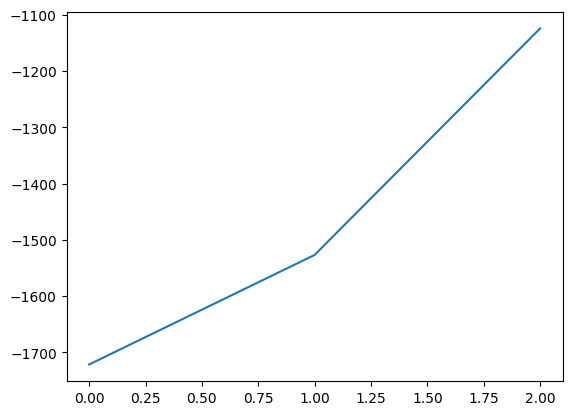

In [63]:
import matplotlib.pyplot as plt
plt.plot(costhistory)


In [10]:
probs = solver.get_probs_func( weights)(params)

In [11]:
solver.check_results(probs)

0

In [ ]:
%load_ext autoreload
%autoreload 2

In [12]:
solver.print_results(probs)

Key: 1110011011111 with probability 0.00087   | correct: False
Key: 1110011101111 with probability 0.00083   | correct: False
Key: 0010011011101 with probability 0.00083   | correct: False
Key: 1110101011100 with probability 0.00083   | correct: False
Key: 1100011011101 with probability 0.00078   | correct: False
Key: 0011111011111 with probability 0.00078   | correct: False
Key: 1110010111111 with probability 0.00078   | correct: False
Key: 1110101101100 with probability 0.00077   | correct: False
Key: 0010011101101 with probability 0.00076   | correct: False
Key: 1100011101101 with probability 0.00074   | correct: False
Key: 1111001011110 with probability 0.00074   | correct: False
Key: 0011111101111 with probability 0.00074   | correct: False
Key: 1111001101110 with probability 0.00070   | correct: False
Key: 1110111011101 with probability 0.00069   | correct: False
Key: 1110100111100 with probability 0.00067   | correct: False
Key: 0011110111111 with probability 0.00067   | correct